# EDA and Feature Engineering

This notebook demonstrates the new single source of truth for data loading and feature engineering using the `src/` package.


In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data.loader import load_config, download_prices
from src.features.engineering import build_features, FEATURE_COLUMNS
from src.models.hmm import walk_forward_predict
from src.models.labeling import smooth_regime_labels

cfg = load_config('../config/config.yaml')


## 1. Raw Data EDA

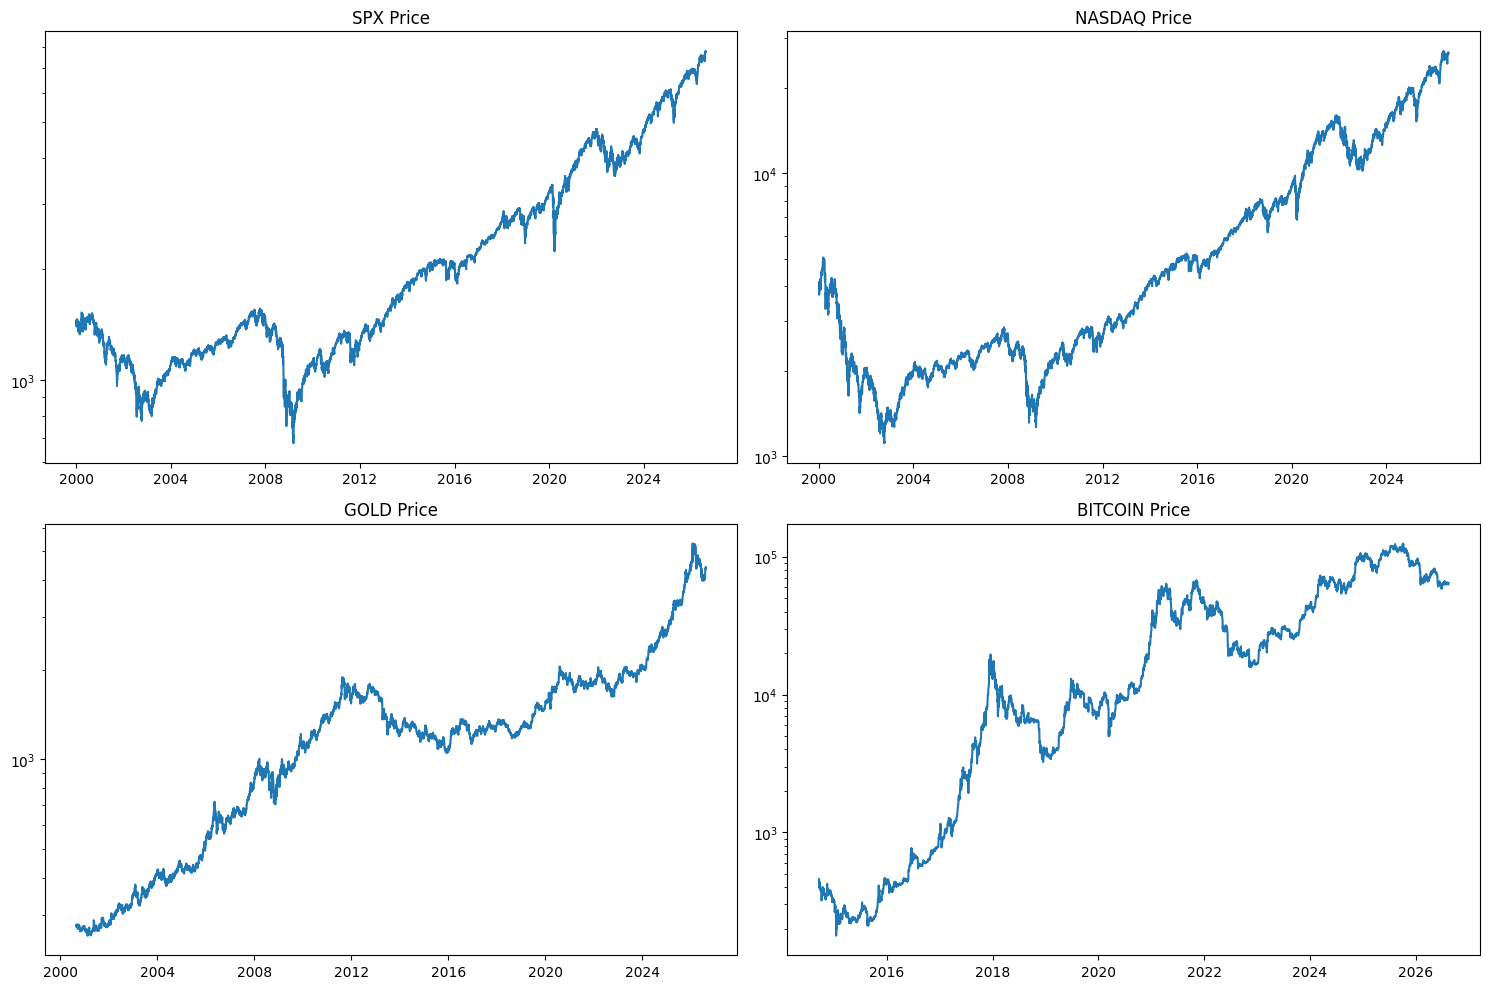

In [2]:
data = download_prices(cfg)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

assets = ['spx', 'nasdaq', 'gold', 'bitcoin']
for i, asset in enumerate(assets):
    df = data[asset]
    axes[i].plot(df.index, df['Close'])
    axes[i].set_title(f"{asset.upper()} Price")
    axes[i].set_yscale('log')

plt.tight_layout()
plt.show()


## 2. Feature Engineering & NaN Warmup

In [3]:
spx = data['spx']

# The single source of truth for features
features = build_features(spx, spx['VIX_Close'])
features['returns'] = spx['Close'].pct_change()

print("Shape with NaNs:", features.shape)
features = features.dropna()
print("Shape after warmup dropna:", features.shape)


Shape with NaNs: (6646, 18)
Shape after warmup dropna: (6646, 18)


## 3. Distributions and Correlations

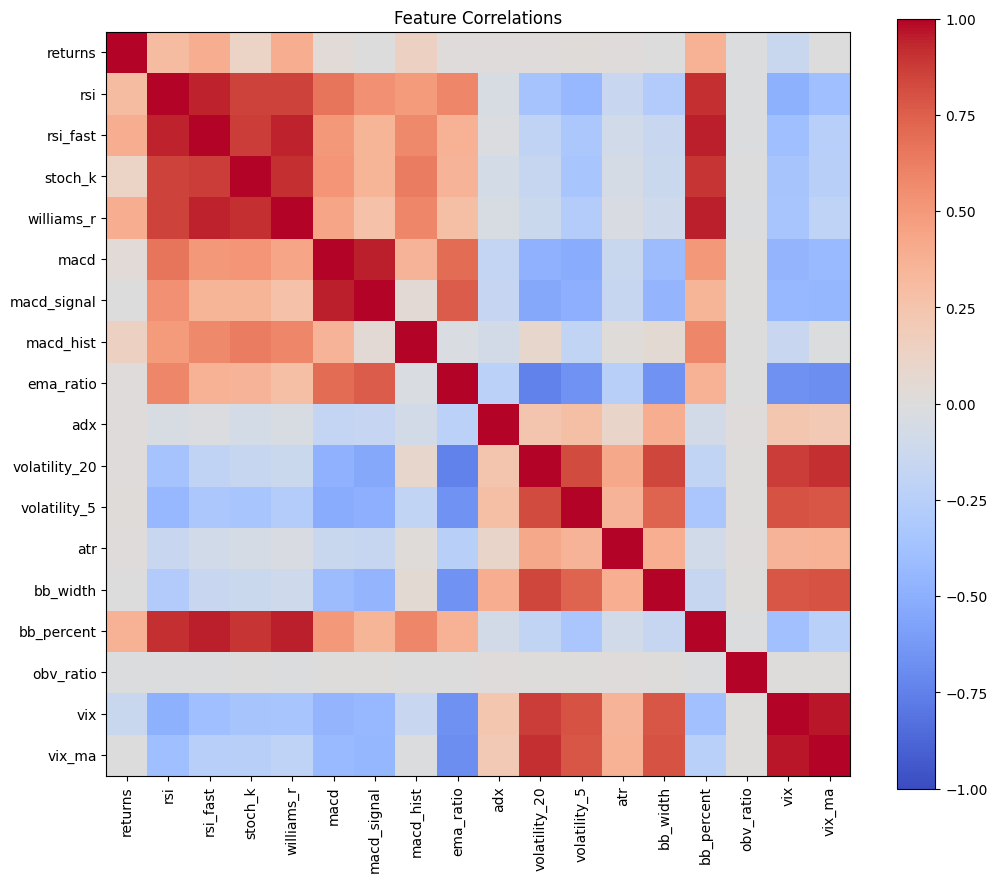

In [4]:
plt.figure(figsize=(12, 10))
corr = features[FEATURE_COLUMNS].corr()
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)
plt.title("Feature Correlations")
plt.show()


## 4. Regime-Conditional Feature Behavior

In [5]:
# Walk-forward prediction to avoid look-ahead
raw_labels, folds = walk_forward_predict(features, FEATURE_COLUMNS, cfg, asset_name='spx')
features['regime'] = smooth_regime_labels(raw_labels, window_size=cfg['model']['smoothing_window'])

regime_stats = features.groupby('regime')[FEATURE_COLUMNS].mean().T
display(regime_stats)


regime,Bull,Crisis,Transition
returns,0.000417,0.000442,0.000170
rsi,57.796650,51.212786,52.030106
rsi_fast,57.705493,53.187887,51.956904
stoch_k,66.133740,60.339918,58.165652
williams_r,-34.307477,-39.033733,-41.766884
macd,15.131923,-2.792669,15.426342
macd_signal,15.978718,-4.179852,15.890137
macd_hist,-0.846795,1.387184,-0.463796
ema_ratio,1.011892,0.994778,1.005433
adx,22.924605,23.130212,19.992909
